# Titanic Passenger Survival: Modeling and Action

- **Course:** ANA 500 Python for Data Science
- **Assignment:** Micro-Project 3
- **Name:** Travis James
- **Dataset:** Titanic passenger data
- **Scope:** Steps 1 through 5 of the data science process - Acquire,
  Prepare, Analyze, Report, Act
- **Earlier work:** https://github.com/OrangeJoe0421/ANA-500-MP1 and
  https://github.com/OrangeJoe0421/ANA-500-MP2

---

## Problem Statement

Micro-Project 2 showed that survival on the Titanic was associated with
sex, ticket class, age, and family size. Each of those results compared one
variable with survival at a time. This project moves from describing those
patterns to modeling them, and asks two questions:

1. **Survival (main question):** which passenger characteristics remain
   associated with survival when they are evaluated together, and how well
   can survival be predicted from them?
2. **Fare (secondary question):** how well can the price of a ticket be
   predicted from passenger and ticket characteristics?

## Hypothesis

The original hypothesis carries forward: women and passengers in higher
ticket classes survived at higher rates than men and passengers in lower
ticket classes. Micro-Project 2 supported it one variable at a time. This
project tests it in a multivariable model, broken into testable parts:

| ID | Hypothesis | How it is tested |
|---|---|---|
| H1 | Sex remains associated with survival after adjusting for class, age, family size, and port | Logistic regression odds ratio |
| H2 | Class remains associated with survival after the same adjustment | Logistic regression odds ratios |
| H3 | The difference between women and men is not the same in every class | Likelihood ratio test for a sex by class interaction |
| H4 | Machine learning models predict survival better than always guessing the most common outcome | Logistic regression and SVM versus a baseline |
| H5 | Fare can be predicted from class, cabin, port, and ticket group size | Linear regression and SVM regression (SVR) |

**A note on model types.** Survival is a yes/no outcome, so it is modeled
with *classification* methods: logistic regression (a regression model for
a binary outcome) and a support vector machine classifier. Fare is a
continuous number, so it is modeled with *regression* methods: linear
regression and support vector regression. Together they cover linear and
SVM approaches for both kinds of target.

---
# Step 1: Acquire

Two files from earlier micro-projects are loaded:

- `titanic_analysis.csv`: the 891 passengers with a known outcome, saved at
  the end of Micro-Project 2. This is the data for the survival models.
- `titanic_clean.csv`: all 1,309 passengers from Micro-Project 1. Fare does
  not depend on the survival outcome, so the fare models can use every
  passenger, and the 418 holdout passengers are scored in Step 5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import chi2
from pathlib import Path

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate,
                                     GroupShuffleSplit, GroupKFold)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, r2_score,
                             mean_absolute_error, root_mean_squared_error)


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 80)


SEED = 42

In [2]:
# Load the two files.
df = pd.read_csv("titanic_analysis.csv")
everyone = pd.read_csv("titanic_clean.csv")

print(f"Labeled passengers (survival models): {len(df):,}")
print(f"All passengers (fare models)        : {len(everyone):,}")

assert len(df) == 891 and df["Survived"].notna().all()
assert len(everyone) == 1309 and everyone["PassengerId"].is_unique
print("Both files match the earlier micro-projects.")

Labeled passengers (survival models): 891
All passengers (fare models)        : 1,309
Both files match the earlier micro-projects.


---
# Step 2: Prepare

Most cleaning was finished in Micro-Project 1. Modeling adds four new
preparation steps:

1. **Choose features** and leave out columns that would leak or duplicate
   information
2. **Encode and scale** the features so both linear and SVM models can use
   them
3. **Split** the data into training and test sets before any model sees it
4. **Set up cross-validation** so model settings are chosen on training
   data only

### 2a. Choose the features

In [3]:
NUM_COLS = ["Age", "FamilySize", "FareLog"]
CAT_COLS = ["Pclass", "Sex", "Embarked"]
FLAG_COLS = ["HasCabin", "AgeWasMissing"]
FEATURES = NUM_COLS + CAT_COLS + FLAG_COLS


X = df[FEATURES].copy()
y = df["Survived"].astype(int)


X["AgeWasMissing"] = X["AgeWasMissing"].astype(int)
print("Feature table:", X.shape)
X.head()

Feature table: (891, 8)


,Age,FamilySize,FareLog,Pclass,Sex,Embarked,HasCabin,AgeWasMissing
0,22.0,2,2.110213,3,male,S,0,0
1,38.0,2,4.280593,1,female,C,1,0
2,26.0,1,2.188856,3,female,S,0,0
3,35.0,2,3.990834,1,female,S,1,0
4,35.0,1,2.202765,3,male,S,0,0


### 2b. Encoding and scaling pipeline

In [4]:
def make_preprocessor(num_cols, cat_cols, flag_cols):
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
         cat_cols),
        ("flag", "passthrough", flag_cols),
    ])


preprocess = make_preprocessor(NUM_COLS, CAT_COLS, FLAG_COLS)



### 2c. Train and test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

print(f"Training set: {len(X_train)} passengers, "
      f"survival rate {y_train.mean():.1%}")
print(f"Test set    : {len(X_test)} passengers, "
      f"survival rate {y_test.mean():.1%}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Training set: 712 passengers, survival rate 38.3%
Test set    : 179 passengers, survival rate 38.5%


**Preparation note:** the ages filled in during Micro-Project 1 used group
medians calculated from all passengers, including those now in the test
set. The calculation never used the survival outcome, so the effect on the
results should be small.

---
# Step 3: Analyze

**Analytical techniques used**

| Technique | Purpose |
|---|---|
| Majority-class baseline | The score to beat: always predict "died" |
| Logistic regression (scikit-learn) | Linear classifier for prediction |
| Linear SVM classifier | Linear decision boundary with a maximum margin |
| RBF SVM classifier | Curved decision boundary that can capture interactions |
| Grid search with 5-fold cross-validation | Choose model settings without touching the test set |
| Logistic regression (statsmodels) | Adjusted odds ratios with confidence intervals for H1 to H3 |
| Likelihood ratio test | Whether a sex by class interaction improves the model (H3) |
| Linear regression and SVR | Predict log fare (H5) |

### 3a. Baseline model

In [7]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
base_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline test accuracy (always predict died): {base_acc:.1%}")

Baseline test accuracy (always predict died): 61.5%


### 3b. Tune and train the survival models

In [11]:
model_specs = {
    "Logistic regression": (
        LogisticRegression(max_iter=1000),
        {"model__C": [0.01, 0.1, 1, 10]}),
    "Linear SVM": (
        SVC(kernel="linear"),
        {"model__C": [0.01, 0.1, 1]}),
    "RBF SVM": (
        SVC(kernel="rbf"),
        {"model__C": [0.5, 1, 3, 10],
         "model__gamma": ["scale", 0.03, 0.1]}),
}


fitted = {}
for name, (estimator, grid) in model_specs.items():
    pipe = Pipeline([("prep", preprocess), ("model", estimator)])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy")
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    print(f"{name:20s} best settings: {search.best_params_}")

Logistic regression  best settings: {'model__C': 1}
Linear SVM           best settings: {'model__C': 1}
RBF SVM              best settings: {'model__C': 1, 'model__gamma': 0.1}


Linear SVM           best settings: {'model__C': 1}


RBF SVM              best settings: {'model__C': 1, 'model__gamma': 0.1}


In [12]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_rows = []
for name, model in fitted.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    row = {"model": name}
    for metric in scoring:
        row[metric] = scores[f"test_{metric}"].mean()
        row[f"{metric}_sd"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)
cv_table = pd.DataFrame(cv_rows).set_index("model")

# Show the mean scores, and accuracy with its spread.
cv_table[["accuracy", "accuracy_sd", "f1", "roc_auc"]].round(3)

,accuracy,accuracy_sd,f1,roc_auc
model,,,,
Logistic regression,0.805,0.016,0.738,0.865
Linear SVM,0.789,0.022,0.715,0.837
RBF SVM,0.824,0.023,0.758,0.856


**Observation:** all three models land between about 79% and 82%
cross-validated accuracy, well above the 61.5% baseline. The fold-to-fold
standard deviation (about 2 points) is similar in size to the gaps between
models, so cross-validation alone does not clearly separate them.

### 3c. Evaluate on the test set

In [13]:

test_rows = []
probs = {}
for name, model in fitted.items():
    pred = model.predict(X_test)
    probs[name] = model.decision_function(X_test)
    test_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, probs[name]),
    })
test_table = pd.DataFrame(test_rows).set_index("model")


test_table.loc["Baseline"] = [base_acc, 0, 0, 0, 0.5]
test_table.round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic regression,0.788,0.746,0.681,0.712,0.837
Linear SVM,0.777,0.738,0.652,0.692,0.818
RBF SVM,0.816,0.810,0.681,0.740,0.862
Baseline,0.615,0.000,0.000,0.000,0.500


**Metric guide:** *precision* is the share of passengers predicted to
survive who actually did. *Recall* is the share of actual survivors the
model found. *F1* balances the two. *ROC AUC* measures how well the
predicted probabilities rank survivors above non-survivors (0.5 is random,
1.0 is perfect).

In [14]:

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY, INK, MUTED, GRIDC = "#9a9893", "#0b0b0b", "#52514e", "#e4e3df"
MODEL_COLORS = {"Logistic regression": BLUE, "Linear SVM": AQUA,
                "RBF SVM": ORANGE, "Baseline": GRAY}

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRIDC,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid.axis": "y", "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11,
})


FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

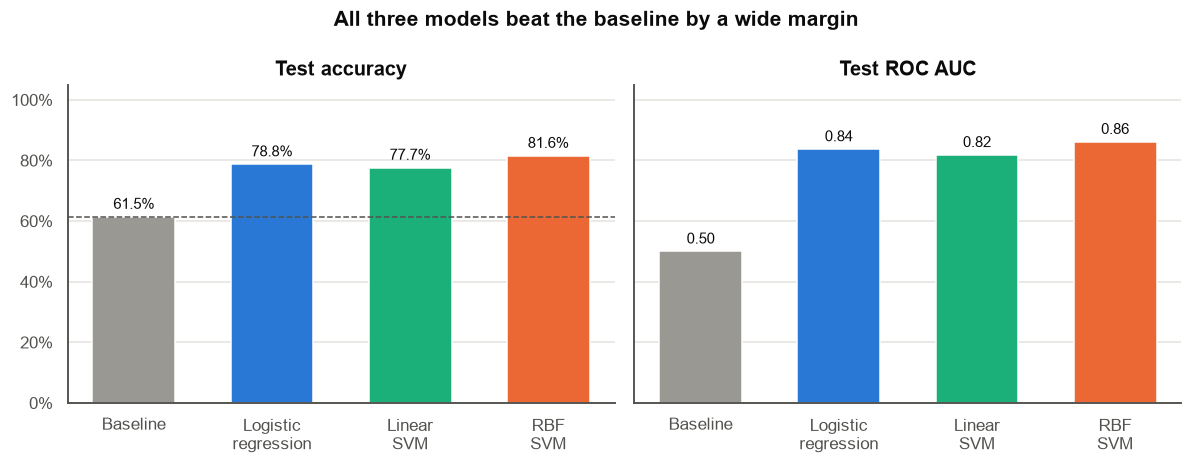

In [15]:

order = ["Baseline", "Logistic regression", "Linear SVM", "RBF SVM"]
plot_df = test_table.loc[order, ["accuracy", "roc_auc"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, metric, label in zip(axes, ["accuracy", "roc_auc"],
                             ["Test accuracy", "Test ROC AUC"]):
    vals = plot_df[metric]
    ax.bar(range(len(vals)), vals, width=0.6,
           color=[MODEL_COLORS[m] for m in vals.index])
    for i, v in enumerate(vals):
        ax.annotate(f"{v:.1%}" if metric == "accuracy" else f"{v:.2f}",
                    (i, v), ha="center", va="bottom", xytext=(0, 3),
                    textcoords="offset points", fontsize=10)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([m.replace(" ", "\n", 1) for m in vals.index])
    ax.set_title(label)
    ax.set_ylim(0, 1.05)
axes[0].axhline(base_acc, ls="--", lw=1, color=MUTED)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
fig.suptitle("All three models beat the baseline by a wide margin",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_model_compare.png")
plt.show()

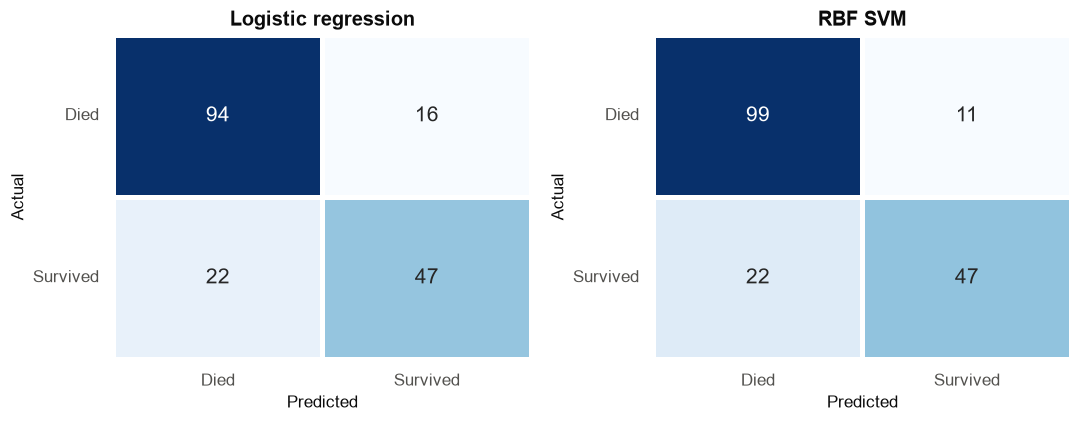

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name in zip(axes, ["Logistic regression", "RBF SVM"]):
    cm = confusion_matrix(y_test, fitted[name].predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                linewidths=2, linecolor="white", annot_kws={"fontsize": 14},
                xticklabels=["Died", "Survived"],
                yticklabels=["Died", "Survived"], ax=ax)
    ax.grid(False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_confusion.png")
plt.show()

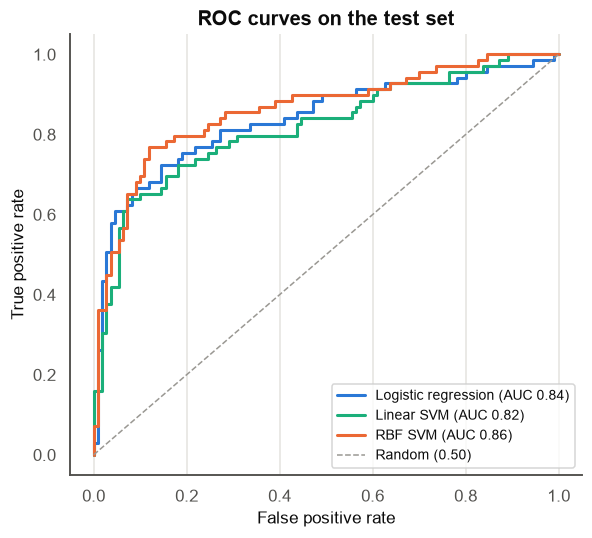

In [17]:
fig, ax = plt.subplots(figsize=(6, 5.2))
for name in ["Logistic regression", "Linear SVM", "RBF SVM"]:
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS[name],
            label=f"{name} (AUC {roc_auc_score(y_test, probs[name]):.2f})")
ax.plot([0, 1], [0, 1], ls="--", lw=1, color=GRAY, label="Random (0.50)")
ax.grid(axis="both")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curves on the test set")
ax.legend(loc="lower right", fontsize=9)
fig.savefig(FIG_DIR / "03_roc.png")
plt.show()

**Observation (H4):** on the 179 test passengers, the RBF SVM reached
81.6% accuracy, logistic regression 78.8%, and the linear SVM 77.7%,
against a baseline of 61.5%. All three also rank passengers well (ROC AUC
of about 0.82 to 0.86). All models miss more survivors than they
wrongly flag: recall (survivors found) is lower than precision.

### 3d. Iteration: does adding Title help?

Data science is iterative, so one alternative feature set was tested.
`Title` (Mr, Mrs, Miss, Master, Rare) was left out of the first models
because it mostly repeats sex and age. It does carry one extra signal,
though: "Master" marks boys, which Micro-Project 2 showed survived far more
often than adult men.

In [19]:

cat_with_title = CAT_COLS + ["Title"]
X_t = df[FEATURES + ["Title"]].copy()
X_t["AgeWasMissing"] = X_t["AgeWasMissing"].astype(int)
X_t_train, X_t_test = X_t.loc[X_train.index], X_t.loc[X_test.index]
prep_t = make_preprocessor(NUM_COLS, cat_with_title, FLAG_COLS)

iter_rows = []
fitted_title = {}
for name in ["Logistic regression", "RBF SVM"]:
    estimator, grid = model_specs[name]
    search = GridSearchCV(Pipeline([("prep", prep_t), ("model", estimator)]),
                          grid, cv=cv, scoring="accuracy")
    search.fit(X_t_train, y_train)
    fitted_title[name] = search.best_estimator_
    iter_rows.append({
        "model": name,
        "cv_acc_without": cv_table.loc[name, "accuracy"],
        "cv_acc_with_title": search.best_score_,
        "test_acc_without": test_table.loc[name, "accuracy"],
        "test_acc_with_title": accuracy_score(
            y_test, search.predict(X_t_test)),
    })
pd.DataFrame(iter_rows).set_index("model").round(3)

,cv_acc_without,cv_acc_with_title,test_acc_without,test_acc_with_title
model,,,,
Logistic regression,0.805,0.831,0.788,0.844
RBF SVM,0.824,0.838,0.816,0.827


**Observation:** adding Title improved both models. Cross-validated
accuracy rose by about 2.6 points for logistic regression and 1.4 points
for the RBF SVM, and test accuracy rose to 84.4% and 82.7%. Because the
gain shows up in both cross-validation and the test set, the Title versions
are carried forward as the *prediction* models in Step 5. With Title added,
the two models are close: the SVM is slightly ahead in cross-validation and
logistic regression is slightly ahead on the test set.

Title is still left out of the *interpretation* model in 3e. It overlaps so
heavily with sex (every "Mr" is male, every "Mrs" and "Miss" is female)
that including both would make the sex odds ratio hard to read.

### 3e. Which factors remain associated with survival? (H1 to H3)

Micro-Project 2 found that sex showed the strongest *bivariate* association
with survival. A bivariate result cannot show whether sex still matters
once class, age, and family size are considered at the same time. A
multivariable logistic regression can, by estimating each variable's
association while holding the others constant.

This model is fit with statsmodels on all 891 labeled passengers, because
the goal here is inference rather
than prediction. Family size is grouped as alone (1), small (2 to 4), and
large (5 or more), because Micro-Project 2 showed its relationship with
survival is not a straight line.

In [21]:

lr_df = df.copy()
lr_df["Female"] = (lr_df["Sex"] == "female").astype(int)
lr_df["Age10"] = lr_df["Age"] / 10       
lr_df["Family"] = pd.cut(lr_df["FamilySize"], bins=[0, 1, 4, 20],
                         labels=["Alone", "Small", "Large"])


formula = ("Survived ~ Female + C(Pclass) + Age10"
           " + C(Family, Treatment('Alone'))"
           " + C(Embarked, Treatment('S'))")
logit = smf.logit(formula, data=lr_df).fit(disp=0)
print(f"Passengers: {int(logit.nobs)}   "
      f"R-squared: {logit.prsquared:.3f}")

Passengers: 891   R-squared: 0.358


In [22]:

labels = {
    "Female": "Female (vs male)",
    "C(Pclass)[T.2]": "2nd class (vs 1st)",
    "C(Pclass)[T.3]": "3rd class (vs 1st)",
    "Age10": "Age, per 10 years",
    "C(Family, Treatment('Alone'))[T.Small]": "Small family (vs alone)",
    "C(Family, Treatment('Alone'))[T.Large]": "Large family (vs alone)",
    "C(Embarked, Treatment('S'))[T.C]": "Cherbourg (vs Southampton)",
    "C(Embarked, Treatment('S'))[T.Q]": "Queenstown (vs Southampton)",
}
ci = logit.conf_int()
odds = pd.DataFrame({
    "odds_ratio": np.exp(logit.params),
    "ci_low": np.exp(ci[0]),
    "ci_high": np.exp(ci[1]),
    "p_value": logit.pvalues,
}).drop(index="Intercept").rename(index=labels)
odds.round(3)

,odds_ratio,ci_low,ci_high,p_value
2nd class (vs 1st),0.287,0.165,0.500,0.000
3rd class (vs 1st),0.092,0.053,0.157,0.000
Small family (vs alone),1.217,0.819,1.808,0.332
Large family (vs alone),0.121,0.050,0.295,0.000
Cherbourg (vs Southampton),1.377,0.858,2.211,0.185
Queenstown (vs Southampton),1.196,0.605,2.362,0.606
Female (vs male),15.105,10.102,22.585,0.000
"Age, per 10 years",0.649,0.551,0.765,0.000


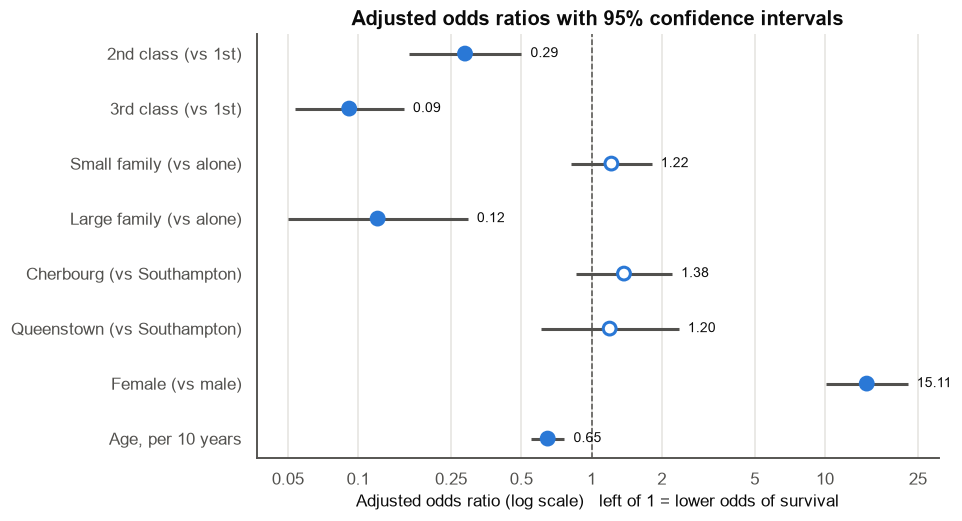

In [23]:

plot_or = odds.iloc[::-1]
sig = (plot_or["ci_low"] > 1) | (plot_or["ci_high"] < 1)

fig, ax = plt.subplots(figsize=(8, 5))
ypos = np.arange(len(plot_or))
ax.hlines(ypos, plot_or["ci_low"], plot_or["ci_high"], color=MUTED, lw=2)
ax.scatter(plot_or["odds_ratio"], ypos, s=70, zorder=3,
           color=np.where(sig, BLUE, "white"), edgecolor=BLUE, lw=2)
for y_i, (o, hi) in enumerate(zip(plot_or["odds_ratio"],
                                  plot_or["ci_high"])):
    ax.annotate(f"{o:.2f}", (hi, y_i), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=9)
ax.axvline(1, ls="--", lw=1, color=MUTED)
ax.set_xscale("log")
ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 5, 10, 25])
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_yticks(ypos)
ax.set_yticklabels(plot_or.index)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_xlabel("Adjusted odds ratio (log scale)   "
              "left of 1 = lower odds of survival")
ax.set_title("Adjusted odds ratios with 95% confidence intervals")
fig.savefig(FIG_DIR / "04_odds_ratios.png")
plt.show()

**Observation (H1, H2):** holding class, age, family size, and port
constant, women had about 15 times the odds of survival of men (95% CI
roughly 10 to 23). Compared with first class, second-class passengers had
about 0.29 times the odds and third-class passengers about 0.09 times the
odds. Both associations are statistically significant, so sex and class
each remain associated with survival when evaluated together. In this
model, the sex odds ratio is the largest in size, but the model alone does
not show that sex *caused* the difference.

Two results change the picture from Micro-Project 2:

- **Port is no longer significant.** Cherbourg's higher bivariate survival
  rate does not hold once class and sex are in the model (confidence
  interval includes 1). This supports the Micro-Project 2 reading that port
  mostly reflected class mix.
- **Small families are no longer different from solo travelers.** The
  bivariate advantage of small families disappears after adjustment, while
  large families (5 or more) keep significantly lower odds.

Each additional 10 years of age is associated with about 35% lower odds of
survival.

In [24]:

formula_int = formula.replace("Female + C(Pclass)", "Female * C(Pclass)")
logit_int = smf.logit(formula_int, data=lr_df).fit(disp=0)

lr_stat = 2 * (logit_int.llf - logit.llf)
df_diff = int(logit_int.df_model - logit.df_model)
p_int = chi2.sf(lr_stat, df_diff)
print(f"Likelihood ratio statistic: {lr_stat:.1f} on {df_diff} df, "
      f"p = {p_int:.1e}")


grid = pd.DataFrame([(f, c) for f in [1, 0] for c in [1, 2, 3]],
                    columns=["Female", "Pclass"])
grid["Age10"] = 3.0
grid["Family"] = pd.Categorical(["Alone"] * 6,
                                categories=["Alone", "Small", "Large"])
grid["Embarked"] = "S"
grid["predicted"] = logit_int.predict(grid)
(grid.assign(Sex=grid["Female"].map({1: "Female", 0: "Male"}))
     .pivot(index="Sex", columns="Pclass", values="predicted").round(2))

Likelihood ratio statistic: 32.1 on 2 df, p = 1.1e-07


Pclass,1,2,3
Sex,,,
Female,0.98,0.93,0.41
Male,0.45,0.13,0.11


**Observation (H3):** adding the sex by class interaction significantly
improves the model. For a 30-year-old traveling alone from Southampton, the
model's predicted survival for women drops sharply in third class, while
for men the largest drop is between first and second class. The gap
between women and men is therefore not constant across classes, which
matches the pattern in the Micro-Project 2 heatmap.

### 3f. Secondary question: predicting fare (H5)

Fare is a continuous number, so this part uses regression. Three choices
keep the test fair:

- **Target:** `FareLog` (log of fare). Fare is heavily right-skewed, and
  the log scale keeps a few very expensive tickets from dominating.
- **Rows:** all 1,309 passengers except the 17 with a fare of 0. Those
  zero fares were flagged in Micro-Project 1 as unusual and are set aside
  for Step 5.
- **Grouped split:** a fare is recorded once per ticket and repeated for
  every passenger on it. If passengers from the same ticket landed in both
  the training and test sets, the model could simply memorize the fare.
  The split therefore keeps each ticket entirely in one set.

In [25]:
everyone["TicketGroup"] = everyone.groupby("Ticket")["Ticket"].transform(
    "size")
paid = everyone[~everyone["FareWasZero"]].copy()

F_NUM = ["Age", "FamilySize", "TicketGroup"]
F_CAT = ["Pclass", "Embarked", "Sex"]
F_FLAG = ["HasCabin"]
Xf = paid[F_NUM + F_CAT + F_FLAG]
yf = paid["FareLog"]
groups = paid["Ticket"]



splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
tr_idx, te_idx = next(splitter.split(Xf, yf, groups))
Xf_train, Xf_test = Xf.iloc[tr_idx], Xf.iloc[te_idx]
yf_train, yf_test = yf.iloc[tr_idx], yf.iloc[te_idx]
shared = set(groups.iloc[tr_idx]) & set(groups.iloc[te_idx])
print(f"Fare rows: {len(paid)}  train {len(tr_idx)}  test {len(te_idx)}")
print(f"Tickets appearing in both sets: {len(shared)}")

Fare rows: 1292  train 1008  test 284
Tickets appearing in both sets: 0


In [26]:

f_prep = make_preprocessor(F_NUM, F_CAT, F_FLAG)
fare_models = {
    "Baseline (mean)": Pipeline([("prep", f_prep),
                                 ("model", DummyRegressor())]),
    "Linear regression": Pipeline([("prep", f_prep),
                                   ("model", LinearRegression())]),
}
svr_search = GridSearchCV(
    Pipeline([("prep", f_prep), ("model", SVR())]),
    {"model__C": [0.3, 1, 3, 10], "model__epsilon": [0.05, 0.1, 0.2],
     "model__gamma": ["scale", 0.1]},
    cv=GroupKFold(n_splits=5), scoring="r2")
svr_search.fit(Xf_train, yf_train, groups=groups.iloc[tr_idx])
print("Best SVR settings:", svr_search.best_params_)
fare_models["SVR"] = svr_search.best_estimator_


fare_rows, fare_pred = [], {}
for name, model in fare_models.items():
    if name != "SVR":
        model.fit(Xf_train, yf_train)
    p = model.predict(Xf_test)
    fare_pred[name] = p
    fare_rows.append({
        "model": name,
        "r2": r2_score(yf_test, p),
        "rmse_log": root_mean_squared_error(yf_test, p),
        "mae_dollars": mean_absolute_error(np.expm1(yf_test),
                                           np.expm1(p)),
    })
fare_table = pd.DataFrame(fare_rows).set_index("model")
fare_table.round(3)

Best SVR settings: {'model__C': 3, 'model__epsilon': 0.05, 'model__gamma': 0.1}


,r2,rmse_log,mae_dollars
model,,,
Baseline (mean),-0.020,0.954,27.633
Linear regression,0.888,0.315,13.870
SVR,0.953,0.205,8.039


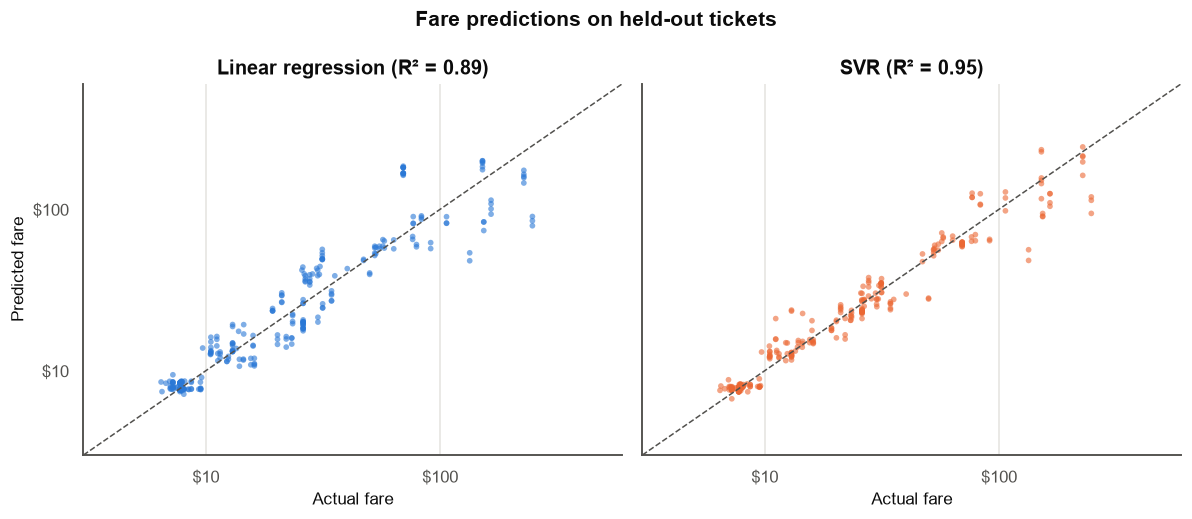

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
actual = np.expm1(yf_test)
for ax, name, color in zip(axes, ["Linear regression", "SVR"],
                           [BLUE, ORANGE]):
    ax.scatter(actual, np.expm1(fare_pred[name]), s=14, alpha=0.6,
               color=color, edgecolor="none")
    lims = [3, 600]
    ax.plot(lims, lims, ls="--", lw=1, color=MUTED)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    fmt = mtick.StrMethodFormatter("${x:,.0f}")
    ax.xaxis.set_major_formatter(fmt)
    ax.yaxis.set_major_formatter(fmt)
    ax.grid(axis="both")
    r2 = fare_table.loc[name, "r2"]
    ax.set_title(f"{name} (R² = {r2:.2f})")
    ax.set_xlabel("Actual fare")
axes[0].set_ylabel("Predicted fare")
fig.suptitle("Fare predictions on held-out tickets",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_fare_pred.png")
plt.show()

In [28]:

lin = fare_models["Linear regression"]
names = lin.named_steps["prep"].get_feature_names_out()
coef = pd.Series(lin.named_steps["model"].coef_, index=names)
pct = (np.exp(coef) - 1).mul(100).round(1).rename("pct_change_in_fare")
pct.sort_values()

cat__Pclass_3      -75.9
cat__Pclass_2      -60.8
cat__Embarked_Q     -9.2
cat__Sex_male       -8.8
cat__Embarked_S     -8.5
num__FamilySize     -3.5
num__Age             2.0
flag__HasCabin       9.7
num__TicketGroup    67.9
Name: pct_change_in_fare, dtype: float64

**Observation (H5):** fare is highly predictable from these features. On
held-out tickets, linear regression explained about 89% of the variation in
log fare (R-squared 0.89, typical error about \$14), and the SVR explained
about 95% (R-squared 0.95, typical error about \$9). The baseline explained
none. In the linear model, holding the other features constant, third-class
fares are about 76% lower than first class and second-class fares about 61%
lower, while each standard deviation increase in ticket group size is
associated with about 68% higher fares, consistent with one fare covering
the whole group. The SVR's higher R-squared suggests some relationships are
not purely linear.

---
# Step 4: Report

### Results against the hypotheses

In [29]:

def or_text(row):
    r = odds.loc[row]
    return (f"OR {r['odds_ratio']:.2f} "
            f"(95% CI {r['ci_low']:.2f} to {r['ci_high']:.2f})")


summary = [
    ("H1", "SUPPORTED", "Sex remains associated after adjustment",
     or_text("Female (vs male)")),
    ("H2", "SUPPORTED", "Class remains associated after adjustment",
     "3rd vs 1st " + or_text("3rd class (vs 1st)")),
    ("H3", "SUPPORTED", "Sex gap differs by class",
     f"Interaction LR test p = {p_int:.1e}"),
    ("H4", "SUPPORTED", "Models beat the baseline",
     f"Test accuracy {test_table.loc['Logistic regression', 'accuracy']:.1%}"
     f" to {iter_rows[0]['test_acc_with_title']:.1%} vs baseline "
     f"{base_acc:.1%}"),
    ("H5", "SUPPORTED", "Fare is predictable",
     f"SVR R2 {fare_table.loc['SVR', 'r2']:.2f}, linear R2 "
     f"{fare_table.loc['Linear regression', 'r2']:.2f}"),
]

for hid, result, claim, evidence in summary:
    print(f"{hid}  {result}: {claim}")
    print(f"    Evidence: {evidence}")
    print()

H1  SUPPORTED: Sex remains associated after adjustment
    Evidence: OR 15.11 (95% CI 10.10 to 22.59)

H2  SUPPORTED: Class remains associated after adjustment
    Evidence: 3rd vs 1st OR 0.09 (95% CI 0.05 to 0.16)

H3  SUPPORTED: Sex gap differs by class
    Evidence: Interaction LR test p = 1.1e-07

H4  SUPPORTED: Models beat the baseline
    Evidence: Test accuracy 78.8% to 84.4% vs baseline 61.5%

H5  SUPPORTED: Fare is predictable
    Evidence: SVR R2 0.95, linear R2 0.89



### Summary of findings

1. **Sex and class both remain associated with survival in a multivariable
   model.** After adjusting for class, age, family size, and port, women
   had about 15 times the odds of survival of men, and third-class
   passengers about 0.09 times the odds of first-class passengers. Both
   associations are statistically significant.
2. **The sex gap differs by class.** A sex by class interaction
   significantly improved the model, consistent with the Micro-Project 2
   heatmap.
3. **Some bivariate patterns did not hold up.** Port of embarkation and
   small family size were associated with survival on their own, but not
   after adjustment. Large families and older age remained associated with
   lower survival odds.
4. **Survival can be predicted well above the baseline.** With the first
   feature set, the RBF SVM reached 81.6% test accuracy and logistic
   regression 78.8%, against a 61.5% baseline. Adding Title raised them to
   82.7% and 84.4%. Differences between the two models are small relative
   to cross-validation variation.
5. **Fare is highly predictable.** Linear regression and SVR explained 89%
   and 95% of the variation in log fare on held-out tickets.

### Limitations

- **Association, not causation.** The odds ratios describe how survival
  differed between groups after adjustment. They do not show why those
  differences occurred.
- **Small test set.** With 179 test passengers, one prediction is worth
  about half a percentage point of accuracy, so small differences between
  models are uncertain.
- **Imputed ages.** About 20% of ages are group-median estimates, which
  limits how precisely age effects can be measured.
- **Sample, not population.** The 891 labeled passengers are a subset of
  the roughly 2,200 people aboard.

---
# Step 5: Act

Acting on the results means applying the models to cases they have not
seen and connecting the findings back to the problem statement.

### 5a. Score the 418 holdout passengers

Micro-Project 1 set aside 418 passengers whose survival outcome is blank.
The two Title models from Step 3d are refit on all 891 labeled passengers
and used to predict survival for them. Logistic regression with Title is
the primary model because it matched the SVM's accuracy and its
probabilities are easy to interpret.

In [30]:

holdout = everyone[everyone["Survived"].isna()].copy()
X_hold = holdout[FEATURES + ["Title"]].copy()
X_hold["AgeWasMissing"] = X_hold["AgeWasMissing"].astype(int)


final_lr = fitted_title["Logistic regression"].fit(X_t, y)
final_svm = fitted_title["RBF SVM"].fit(X_t, y)
holdout["PredProb_LR"] = final_lr.predict_proba(X_hold)[:, 1]
holdout["PredSurvived_LR"] = final_lr.predict(X_hold)
holdout["PredSurvived_SVM"] = final_svm.predict(X_hold)

agree = (holdout["PredSurvived_LR"] == holdout["PredSurvived_SVM"]).mean()
print(f"Holdout passengers scored: {len(holdout)}")
print(f"Predicted survivors (logistic, yes/no labels): "
      f"{holdout['PredSurvived_LR'].mean():.1%}")
print(f"Average predicted probability (logistic)     : "
      f"{holdout['PredProb_LR'].mean():.1%}")
print(f"Logistic and SVM labels agree on {agree:.1%} of passengers")

Holdout passengers scored: 418
Predicted survivors (logistic, yes/no labels): 40.9%
Average predicted probability (logistic)     : 41.1%
Logistic and SVM labels agree on 92.1% of passengers


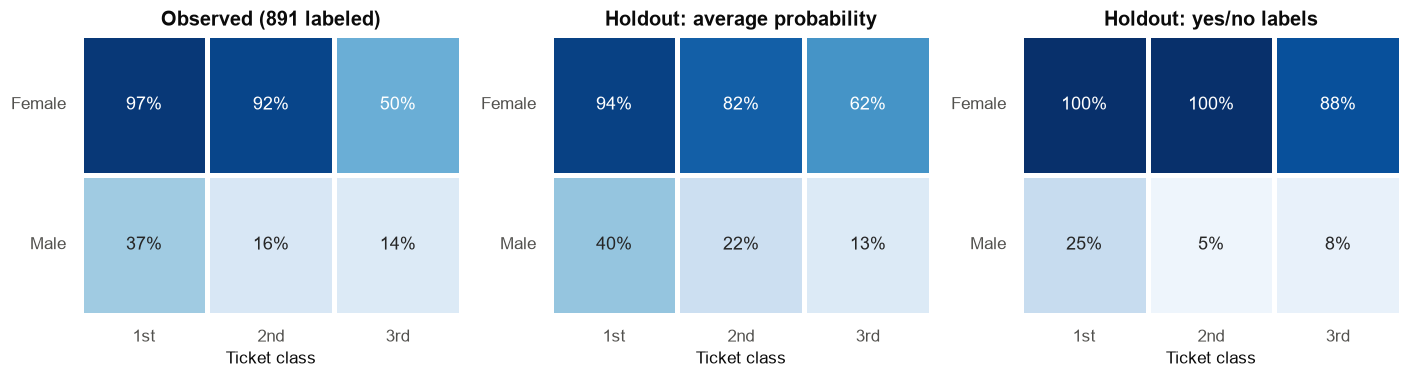

Observed (891 labeled)
Pclass   1st   2nd   3rd
Sex                     
Female  0.97  0.92  0.50
Male    0.37  0.16  0.14

Holdout: average probability
Pclass   1st   2nd   3rd
Sex                     
Female  0.94  0.82  0.62
Male    0.40  0.22  0.13

Holdout: yes/no labels
Pclass   1st   2nd   3rd
Sex                     
Female  1.00  1.00  0.88
Male    0.25  0.05  0.08



In [31]:

CLASS_NAMES = {1: "1st", 2: "2nd", 3: "3rd"}


def by_sex_class(data, col):
    return (data.pivot_table(index="Sex", columns="Pclass", values=col,
                             aggfunc="mean")
                .rename(index=str.title, columns=CLASS_NAMES))


panels = [
    (by_sex_class(df, "Survived"), "Observed (891 labeled)"),
    (by_sex_class(holdout, "PredProb_LR"),
     "Holdout: average probability"),
    (by_sex_class(holdout, "PredSurvived_LR"), "Holdout: yes/no labels"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (data, title) in zip(axes, panels):
    sns.heatmap(data, annot=True, fmt=".0%", cmap="Blues", vmin=0, vmax=1,
                cbar=False, linewidths=2, linecolor="white",
                annot_kws={"fontsize": 12}, ax=ax)
    ax.grid(False)
    ax.set_title(title)
    ax.set_xlabel("Ticket class")
    ax.set_ylabel("")
    ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_holdout.png")
plt.show()

for data, title in panels:
    print(title)
    print(data.round(2))
    print()

**Observation:** the average predicted probability follows the same sex
and class pattern as the observed data, highest for first-class women (94%)
and lowest for third-class men (13%). Overall the model expects about 41%
of holdout passengers survived, close to the 38.4% observed among labeled
passengers. The yes/no labels show a much sharper split (every first- and
second-class woman predicted to survive, 5% to 25% of men). That is a side
effect of rounding each probability at 0.5, not a separate finding, which is
why the average probability is the better summary. Logistic regression and
the SVM give the same label for 92% of passengers.

The predictions are saved for comparison if outcomes for these passengers
become available. Until then they cannot be scored, so the 179-passenger
test set remains the evidence for accuracy.

### 5b. Estimate typical fares for the 17 zero-fare tickets

Micro-Project 1 kept 17 fares of 0 and flagged them instead of guessing a
value. The fare model can now estimate what a comparable paid ticket would
have cost. This does not say what these passengers actually paid or why
their fare was recorded as 0; it only gives a reference value. Each
estimate is checked against the median fare of similar paid tickets.

In [32]:

zero = everyone[everyone["FareWasZero"]].copy()
zero["EstFare"] = np.expm1(
    fare_models["SVR"].predict(zero[F_NUM + F_CAT + F_FLAG])).round(2)



def similar_median(row):
    match = paid[(paid["Pclass"] == row["Pclass"])
                 & (paid["TicketGroup"] == row["TicketGroup"])
                 & (paid["HasCabin"] == row["HasCabin"])]
    return match["Fare"].median()


zero["SimilarMedian"] = zero.apply(similar_median, axis=1).round(2)
zero["Gap"] = (zero["EstFare"] - zero["SimilarMedian"]).round(2)
check = (zero.groupby(["Pclass", "TicketGroup", "FamilySize"])
             [["EstFare", "SimilarMedian", "Gap"]].mean().round(2))
check["passengers"] = zero.groupby(
    ["Pclass", "TicketGroup", "FamilySize"]).size()
check

EstFare  SimilarMedian    Gap  passengers
Pclass TicketGroup FamilySize                                           
1      1           1             27.52          27.81  -0.29           5
       2           1             54.78          60.59  -5.80           2
2      1           1             12.52          13.00  -0.48           3
       3           1             37.54          29.00   8.54           3
3      4           1             33.14          20.58  12.56           4

**Observation:** for 10 of the 17 passengers, the estimate is within about
$3 of the median for similar paid tickets. The model overestimates two
groups: three second-class passengers on a shared 3-person ticket (about
\$9 high) and four third-class passengers listed as traveling alone on a
4-person ticket (about \$14 high). Solo travelers on a 4-person ticket are
rare in the training data, so the model is extrapolating there. Estimates
for unusual combinations should be checked against similar records before
they are relied on.

### 5c. Connecting the results to the problem statement

**Survival question.** The multivariable models answer the question raised
by the Micro-Project 2 feedback: sex and class each remain significantly
associated with survival when evaluated together, and the size of the sex
gap depends on class. Port and small family size, which looked important on
their own, do not add information once these are accounted for. 

**Model choice.** For *explaining* survival, the statsmodels logistic
regression is the right tool, because its odds ratios and confidence
intervals are directly interpretable. For *predicting* survival, the Title
versions of logistic regression and the RBF SVM performed about the same
(84.4% and 82.7% test accuracy). Logistic regression is recommended because
it is simpler and its probabilities can be read directly, but a larger test
set or repeated splits would be needed to show that either is truly
better.

**Fare question.** Fare can be estimated with a typical error of about \$9
from class, cabin, port, and ticket group size. That makes the model useful
for flagging fare records that look out of line, as long as estimates for
rare combinations are sanity-checked, as Step 5b showed.

**Next steps.** Confirm the model comparison with repeated
cross-validation, test the sex by class interaction inside the machine
learning pipelines, and move age imputation inside the pipeline to remove
the small leakage noted in Step 2.

In [33]:
# Save the outputs of Step 5 so they can be reused or checked later.
cols = ["PassengerId", "Sex", "Pclass", "Age", "PredSurvived_SVM",
        "PredSurvived_LR", "PredProb_LR"]
holdout[cols].to_csv("holdout_predictions.csv", index=False)
zero[["PassengerId", "Name", "Pclass", "Ticket", "EstFare"]].to_csv(
    "zero_fare_estimates.csv", index=False)
print("Saved holdout_predictions.csv and zero_fare_estimates.csv")
print("Figures saved:")
for png in sorted(FIG_DIR.glob("*.png")):
    print("  ", png.name)

Saved holdout_predictions.csv and zero_fare_estimates.csv
Figures saved:
   01_model_compare.png
   01_overall.png
   02_confusion.png
   02_sex_class.png
   03_heatmap.png
   03_roc.png
   04_age.png
   04_odds_ratios.png
   05_fare.png
   05_fare_pred.png
   06_family.png
   06_holdout.png
   07_port.png
   08_corr.png
